In [2]:
import pandas as pd
import matplotlib.pyplot as plt

EXCEL_FILE = "normals.xlsx"         
SHEETS = {"Idabel": "Idabel", "Boise_City": "Boise City"}
COLORS = {"Idabel": "#FF6600", "Boise City": "#1F4E79"}
MONTHS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

def monthly(sheet):
    d = pd.read_excel(EXCEL_FILE, sheet_name=sheet)
    d.columns = [c.strip().lower() for c in d.columns]
    pcpn_col = [c for c in d.columns if "pcpn" in c][0]    
    d["pcpn_daily"] = d[pcpn_col].diff()
    d.loc[d.index[0], "pcpn_daily"] = d[pcpn_col].iloc[0]
    d.loc[d["pcpn_daily"] < 0, "pcpn_daily"] = 0
    d["month"] = pd.PeriodIndex(
        pd.date_range("2021-01-01", periods=len(d), freq="D"), freq="M").month
    return pd.DataFrame({
        "month": range(1, 13),
        "MeanT":  d.groupby("month")["avgt"].mean().values,
        "Precip": d.groupby("month")["pcpn_daily"].sum().values,
    })

data = {label: monthly(sheet) for sheet, label in SHEETS.items()}



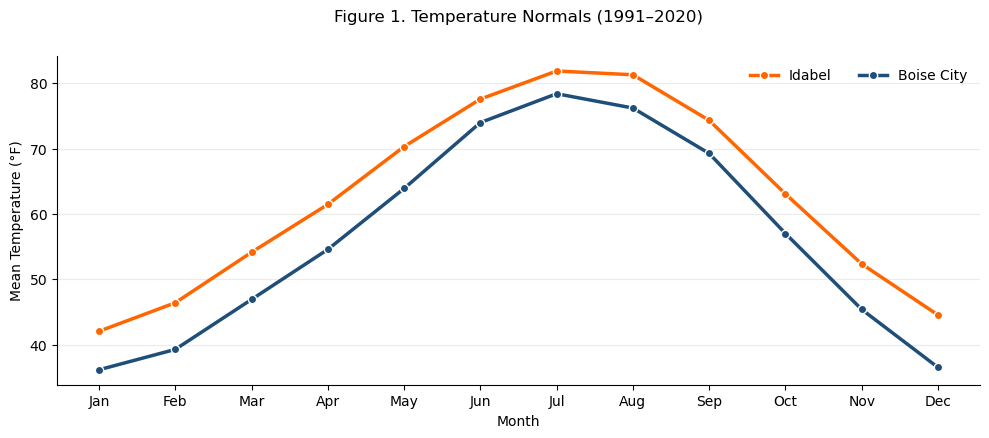

In [7]:
# Figure 1 — Temperature normals
fig, ax = plt.subplots(figsize=(10, 4.5))
for label, m in data.items():
    ax.plot(m["month"], m["MeanT"], marker="o", linewidth=2.5,
            color=COLORS[label], markeredgecolor="white", label=label)
ax.set_xticks(range(1, 13)); ax.set_xticklabels(MONTHS)
ax.set_xlabel("Month"); ax.set_ylabel("Mean Temperature (°F)")
ax.set_title("Figure 1. Temperature Normals (1991–2020)", y=1.08)
ax.grid(axis="y", alpha=0.25); ax.set_axisbelow(True)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
fig.savefig("Figure1_Temperature_Normals.png", dpi=300, bbox_inches="tight")
plt.show()



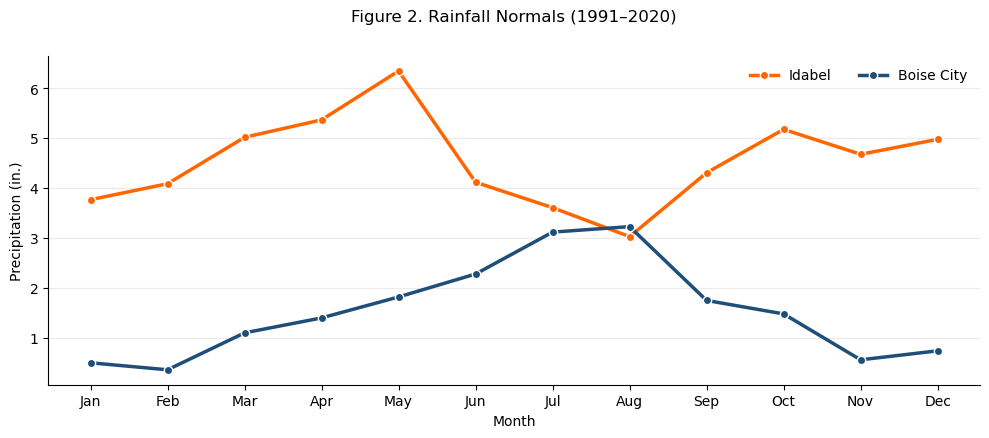

In [8]:
# Figure 2 — Rainfall normals
fig, ax = plt.subplots(figsize=(10, 4.5))
for label, m in data.items():
    ax.plot(m["month"], m["Precip"], marker="o", linewidth=2.5,
            color=COLORS[label], markeredgecolor="white", label=label)
ax.set_xticks(range(1, 13)); ax.set_xticklabels(MONTHS)
ax.set_xlabel("Month"); ax.set_ylabel("Precipitation (in.)")
ax.set_title("Figure 2. Rainfall Normals (1991–2020)",y=1.08)
ax.grid(axis="y", alpha=0.25); ax.set_axisbelow(True)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
fig.savefig("Figure2_Rainfall_Normals.png", dpi=300, bbox_inches="tight")
plt.show()